In [1]:
# DEFAULT
import numpy as np
import pickle
from collections import defaultdict

# CUSTOM
from cora.momenta import get_max_momentum_list, get_sel_momentum_list_polarisation, get_sel_momentum_indices
from hadrana.misc.lhpc.lhpc_visualise import *

In [2]:
def dd():
    return defaultdict(dd)

In [3]:
ensemble    = 'N204'
# ensemble    = 'H106'
pol         = 'Z'
n_bst       = 100

nsquares    = [0, 1, 2, 3, 4, 5, 6, 8]
source_sets = ['2']
# source_sets = ['2', '4']

In [4]:
# data was saved as e.g. H106-RATIOS-AXIAL-CURZ-POLZ-NSQUARE0-NBST100-SOURCE-SET2.pkl

def load_ratios(ensemble, nsquare, source_set):
    tag  = f"{ensemble}-RATIOS-PSEUDOSCALAR-POL{pol}-NSQUARE{nsquare}-NBST{n_bst}-SOURCE-SET{source_set}.pkl"
    path = f"/glurch/scratch/kic04594/bootstrap_data/lhp_vs_reg/{ensemble}/pseudoscalar/{tag}"
    with open(path, "rb") as f:
        return pickle.load(f)

ratios = dd()
for s in source_sets:
    for n in nsquares:
        ratios[s][n] = load_ratios(ensemble, n, s)

In [5]:
max_momentum_list    = get_max_momentum_list(8)
print(f"Total Available momentum configurations: {len(max_momentum_list)}")
print(max_momentum_list)
print()

Total Available momentum configurations: 93
[(0, 0, 0), (0, 0, 1), (0, 0, -1), (0, 0, 2), (0, 0, -2), (0, 1, 0), (0, -1, 0), (0, 1, 1), (0, -1, 1), (0, 1, -1), (0, -1, -1), (0, 1, 2), (0, -1, 2), (0, 1, -2), (0, -1, -2), (0, 2, 0), (0, -2, 0), (0, 2, 1), (0, -2, 1), (0, 2, -1), (0, -2, -1), (0, 2, 2), (0, -2, 2), (0, 2, -2), (0, -2, -2), (1, 0, 0), (-1, 0, 0), (1, 0, 1), (-1, 0, 1), (1, 0, -1), (-1, 0, -1), (1, 0, 2), (-1, 0, 2), (1, 0, -2), (-1, 0, -2), (1, 1, 0), (-1, 1, 0), (1, -1, 0), (-1, -1, 0), (1, 1, 1), (-1, 1, 1), (1, -1, 1), (1, 1, -1), (1, -1, -1), (-1, 1, -1), (-1, -1, 1), (-1, -1, -1), (1, 1, 2), (-1, 1, 2), (1, -1, 2), (1, 1, -2), (1, -1, -2), (-1, 1, -2), (-1, -1, 2), (-1, -1, -2), (1, 2, 0), (-1, 2, 0), (1, -2, 0), (-1, -2, 0), (1, 2, 1), (-1, 2, 1), (1, -2, 1), (1, 2, -1), (1, -2, -1), (-1, 2, -1), (-1, -2, 1), (-1, -2, -1), (2, 0, 0), (-2, 0, 0), (2, 0, 1), (-2, 0, 1), (2, 0, -1), (-2, 0, -1), (2, 0, 2), (-2, 0, 2), (2, 0, -2), (-2, 0, -2), (2, 1, 0), (-2, 1, 0), (2,

In [6]:
ratios_per_nsquare = dd()

k = 2  # index for nz in (nx, ny, nz) -> (0, 1, 2)

for s in source_sets:
    for n in nsquares:
        print(f">>> NSQUARE = {n}, POL = {pol}")

        # momentum selection
        sel_mom_list = get_sel_momentum_list_polarisation(n, pol)
        sel_idx      = get_sel_momentum_indices(n, pol)

        print("MOMENTUM CONFIGURATIONS")
        print(sel_mom_list)

        print("MOMENTUM INDICES")
        print(sel_idx)
        print()

        # no forward limit for pseudoscalar data
        if len(sel_idx) == 0:
            continue

        # q^z ~ n_z (up to 2pi/L 
        n_z = np.array([m[k] for m in sel_mom_list], dtype=float)   # shape (Nmom,)
        if np.any(n_z == 0):
            raise RuntimeError(f"Found occurance of n_z = 0 in pol = {pol} selection for nsquare = {n}.")

        src_snk_seps = list(ratios[s][n].keys())
        for t in src_snk_seps:
            arr = ratios[s][n][t]           # (n_bst, n_src, 93, n_tau)
            arr_sel = arr[:, :, sel_idx, :] # (n_bst, n_src, n_mom_sel, n_tau)
            # divide data by nz
            arr_red = arr_sel / n_z[None, None, :, None] 
            ratios_per_nsquare[s][n][t] = np.mean(arr_red, axis=2) # -> (n_bst, n_src, n_tau)

>>> NSQUARE = 0, POL = Z
MOMENTUM CONFIGURATIONS
[]
MOMENTUM INDICES
[]

>>> NSQUARE = 1, POL = Z
MOMENTUM CONFIGURATIONS
[(0, 0, 1), (0, 0, -1)]
MOMENTUM INDICES
[1, 2]

>>> NSQUARE = 2, POL = Z
MOMENTUM CONFIGURATIONS
[(0, 1, 1), (0, -1, 1), (0, 1, -1), (0, -1, -1), (1, 0, 1), (-1, 0, 1), (1, 0, -1), (-1, 0, -1)]
MOMENTUM INDICES
[7, 8, 9, 10, 27, 28, 29, 30]

>>> NSQUARE = 3, POL = Z
MOMENTUM CONFIGURATIONS
[(1, 1, 1), (-1, 1, 1), (1, -1, 1), (1, 1, -1), (1, -1, -1), (-1, 1, -1), (-1, -1, 1), (-1, -1, -1)]
MOMENTUM INDICES
[39, 40, 41, 42, 43, 44, 45, 46]

>>> NSQUARE = 4, POL = Z
MOMENTUM CONFIGURATIONS
[(0, 0, 2), (0, 0, -2)]
MOMENTUM INDICES
[3, 4]

>>> NSQUARE = 5, POL = Z
MOMENTUM CONFIGURATIONS
[(0, 1, 2), (0, -1, 2), (0, 1, -2), (0, -1, -2), (0, 2, 1), (0, -2, 1), (0, 2, -1), (0, -2, -1), (1, 0, 2), (-1, 0, 2), (1, 0, -2), (-1, 0, -2), (2, 0, 1), (-2, 0, 1), (2, 0, -1), (-2, 0, -1)]
MOMENTUM INDICES
[11, 12, 13, 14, 17, 18, 19, 20, 31, 32, 33, 34, 69, 70, 71, 72]

>>> NSQUARE

In [7]:
def x_vals(nsquare: int, tsep: int):
    n_tau = tsep + 1
    if nsquare == 0:
        x = np.arange(n_tau) - (n_tau - 1) / 2
    else:
        x = np.arange(n_tau)
    return x

def y_est_err(data: dict, src_id: int, nsquare: int, tsep: int):
    y_bst = data[nsquare][tsep]
    y_est = np.mean(y_bst[:, src_id, :], axis=0)
    y_err = np.std(y_bst[:, src_id, :], axis=0, ddof=1)
    return y_est, y_err

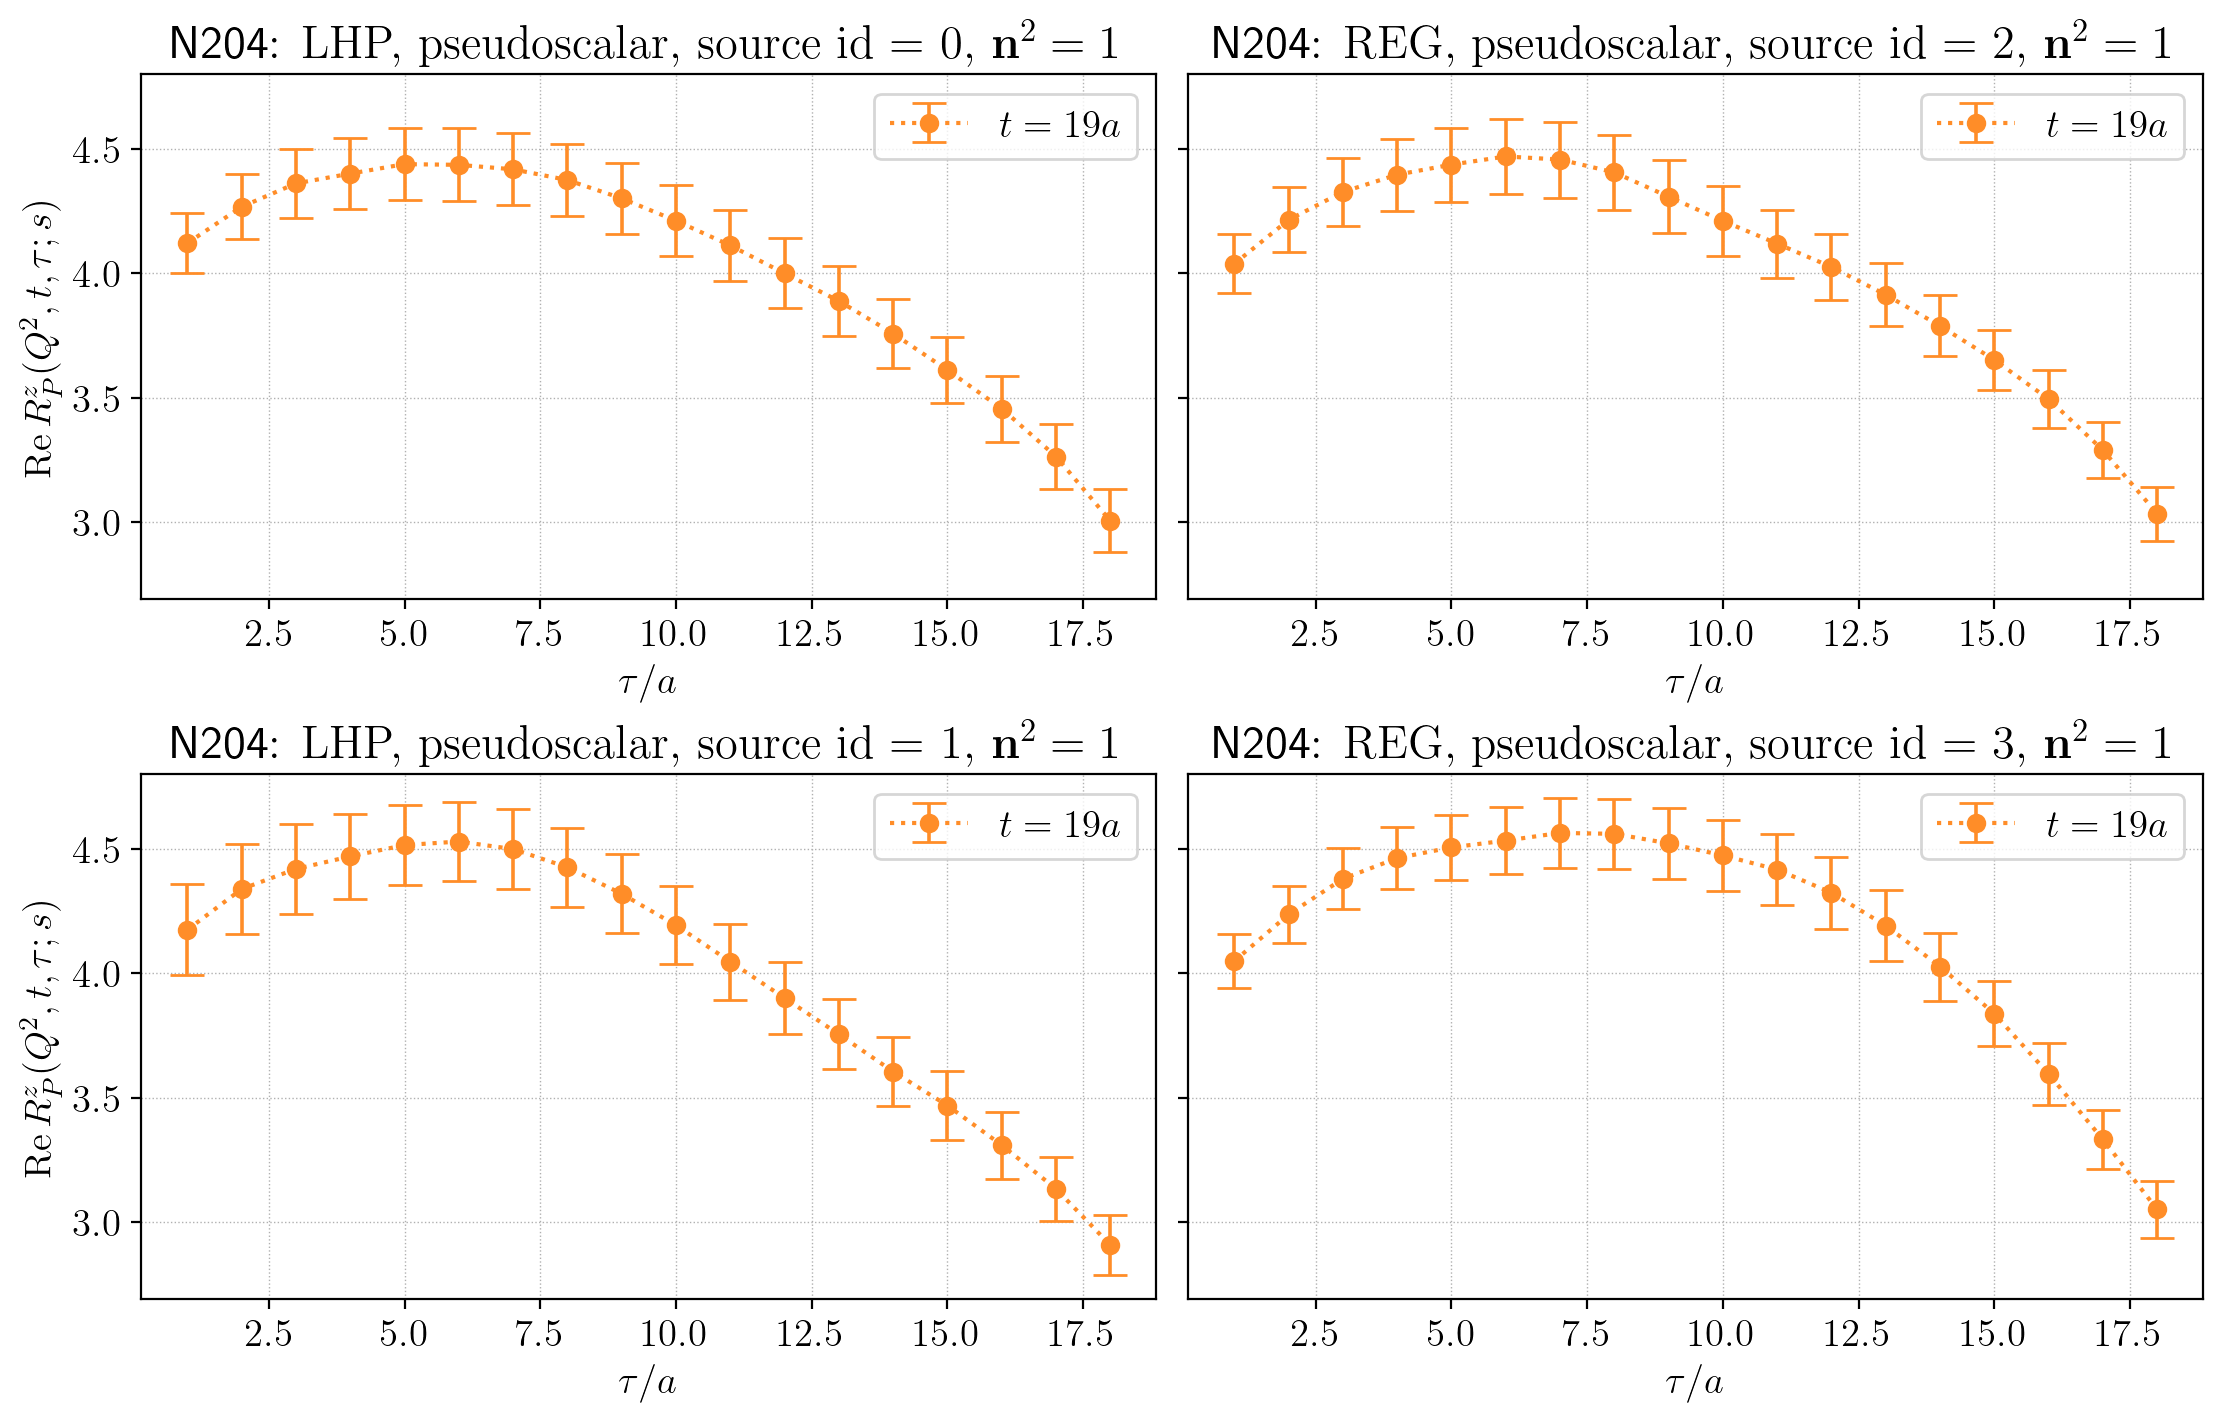

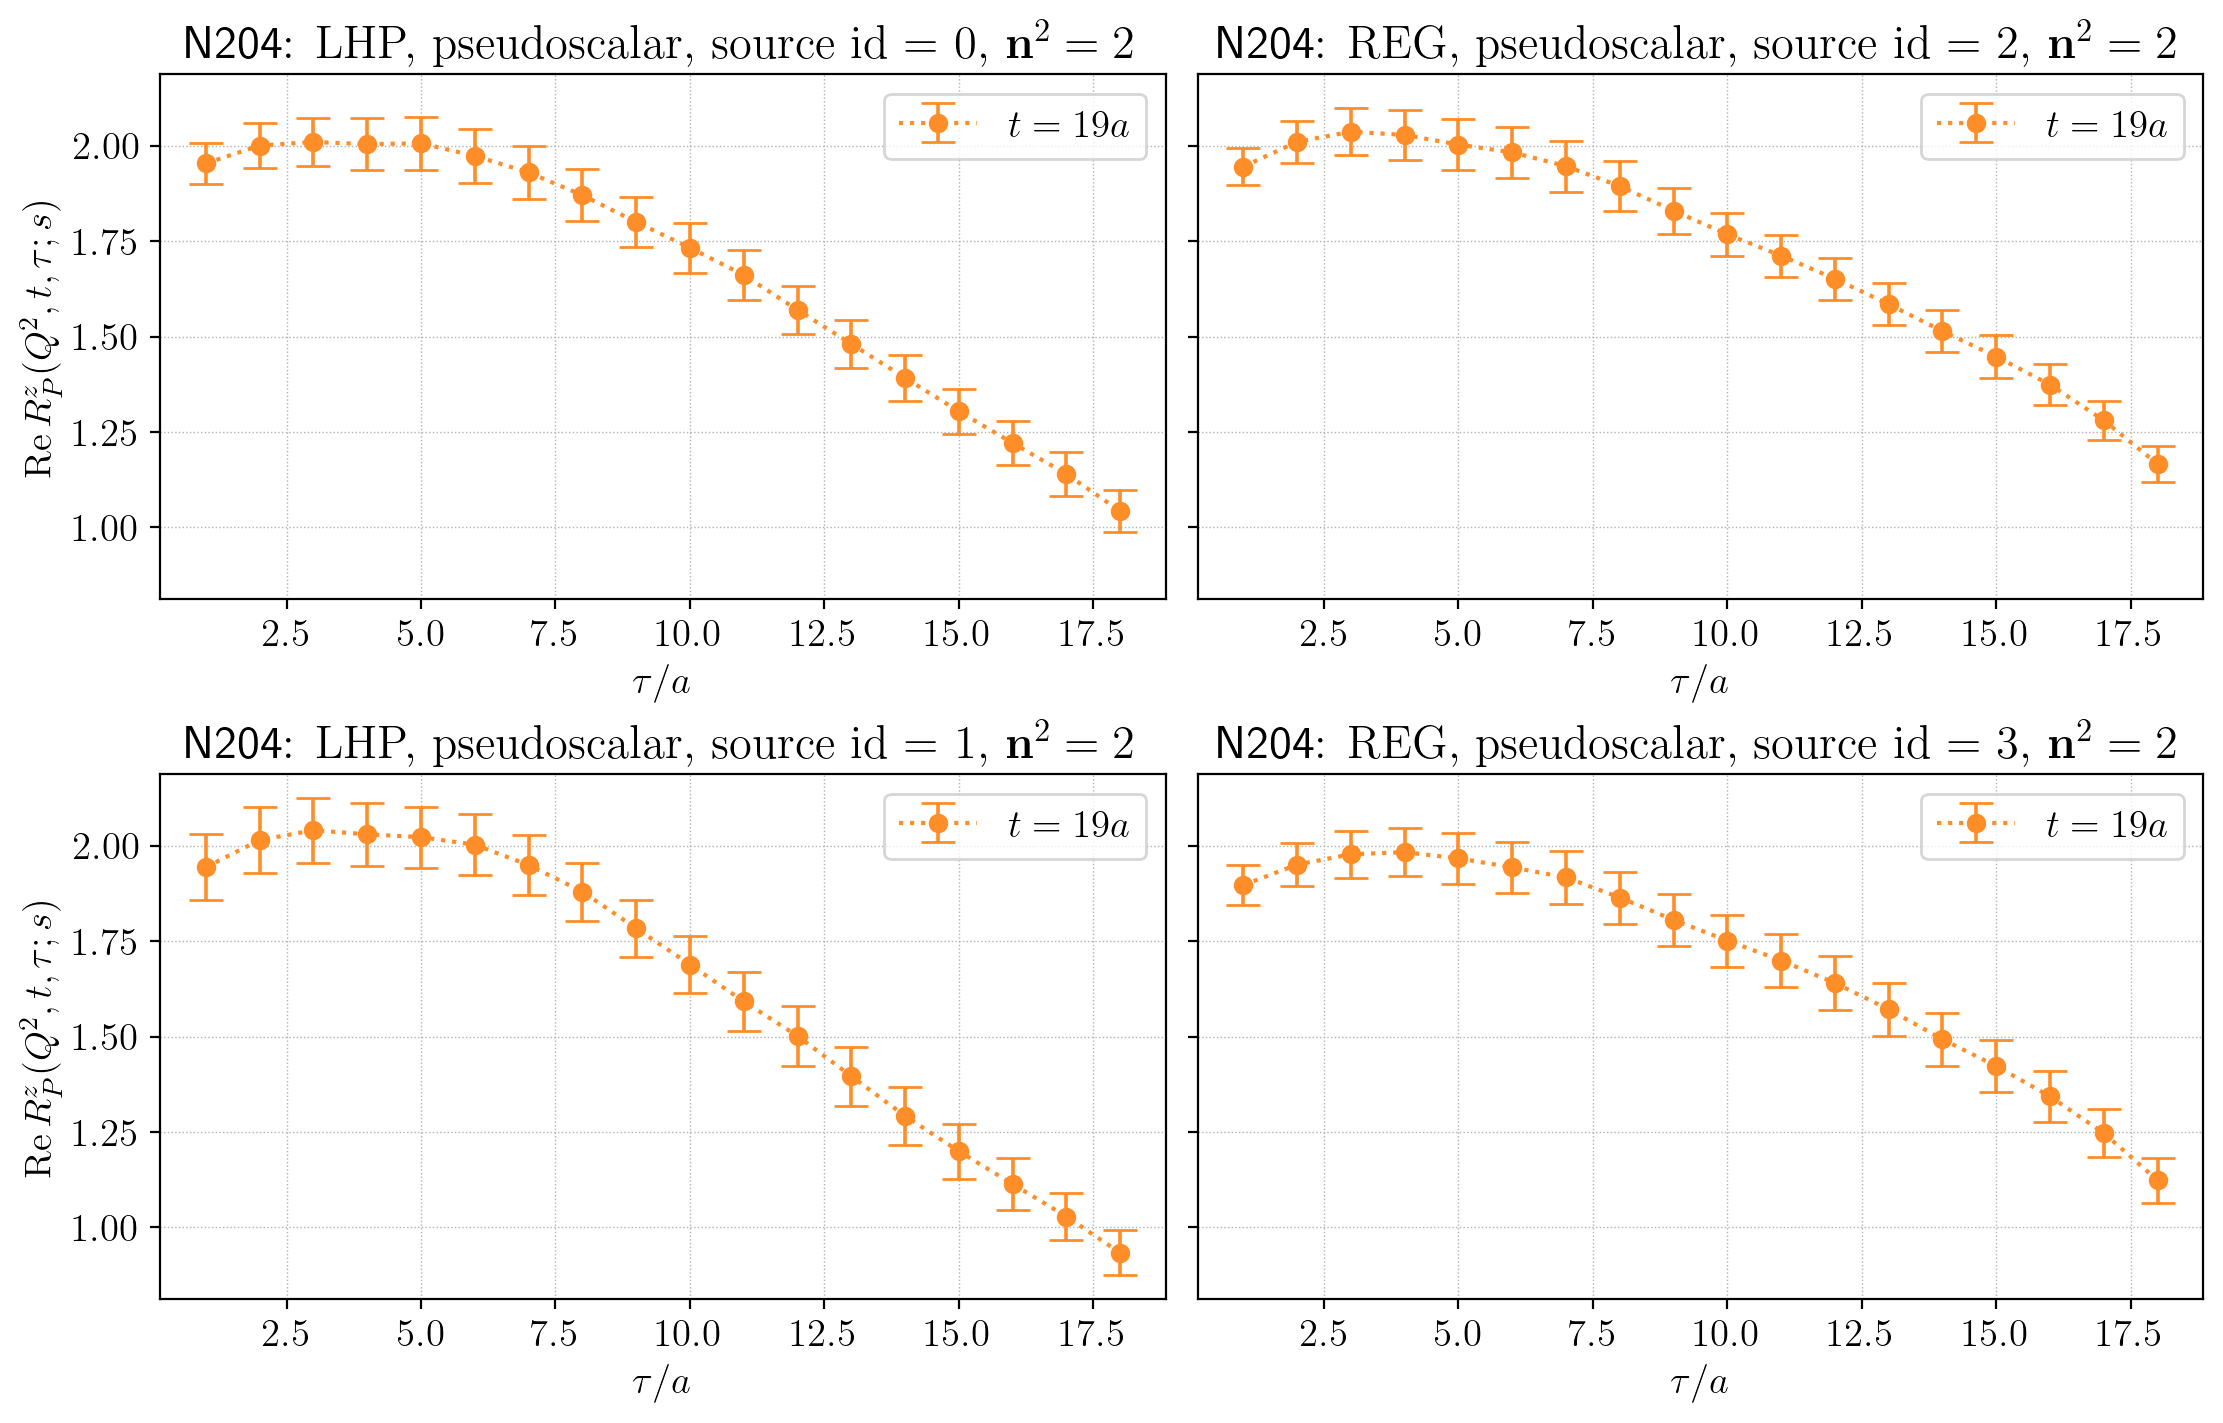

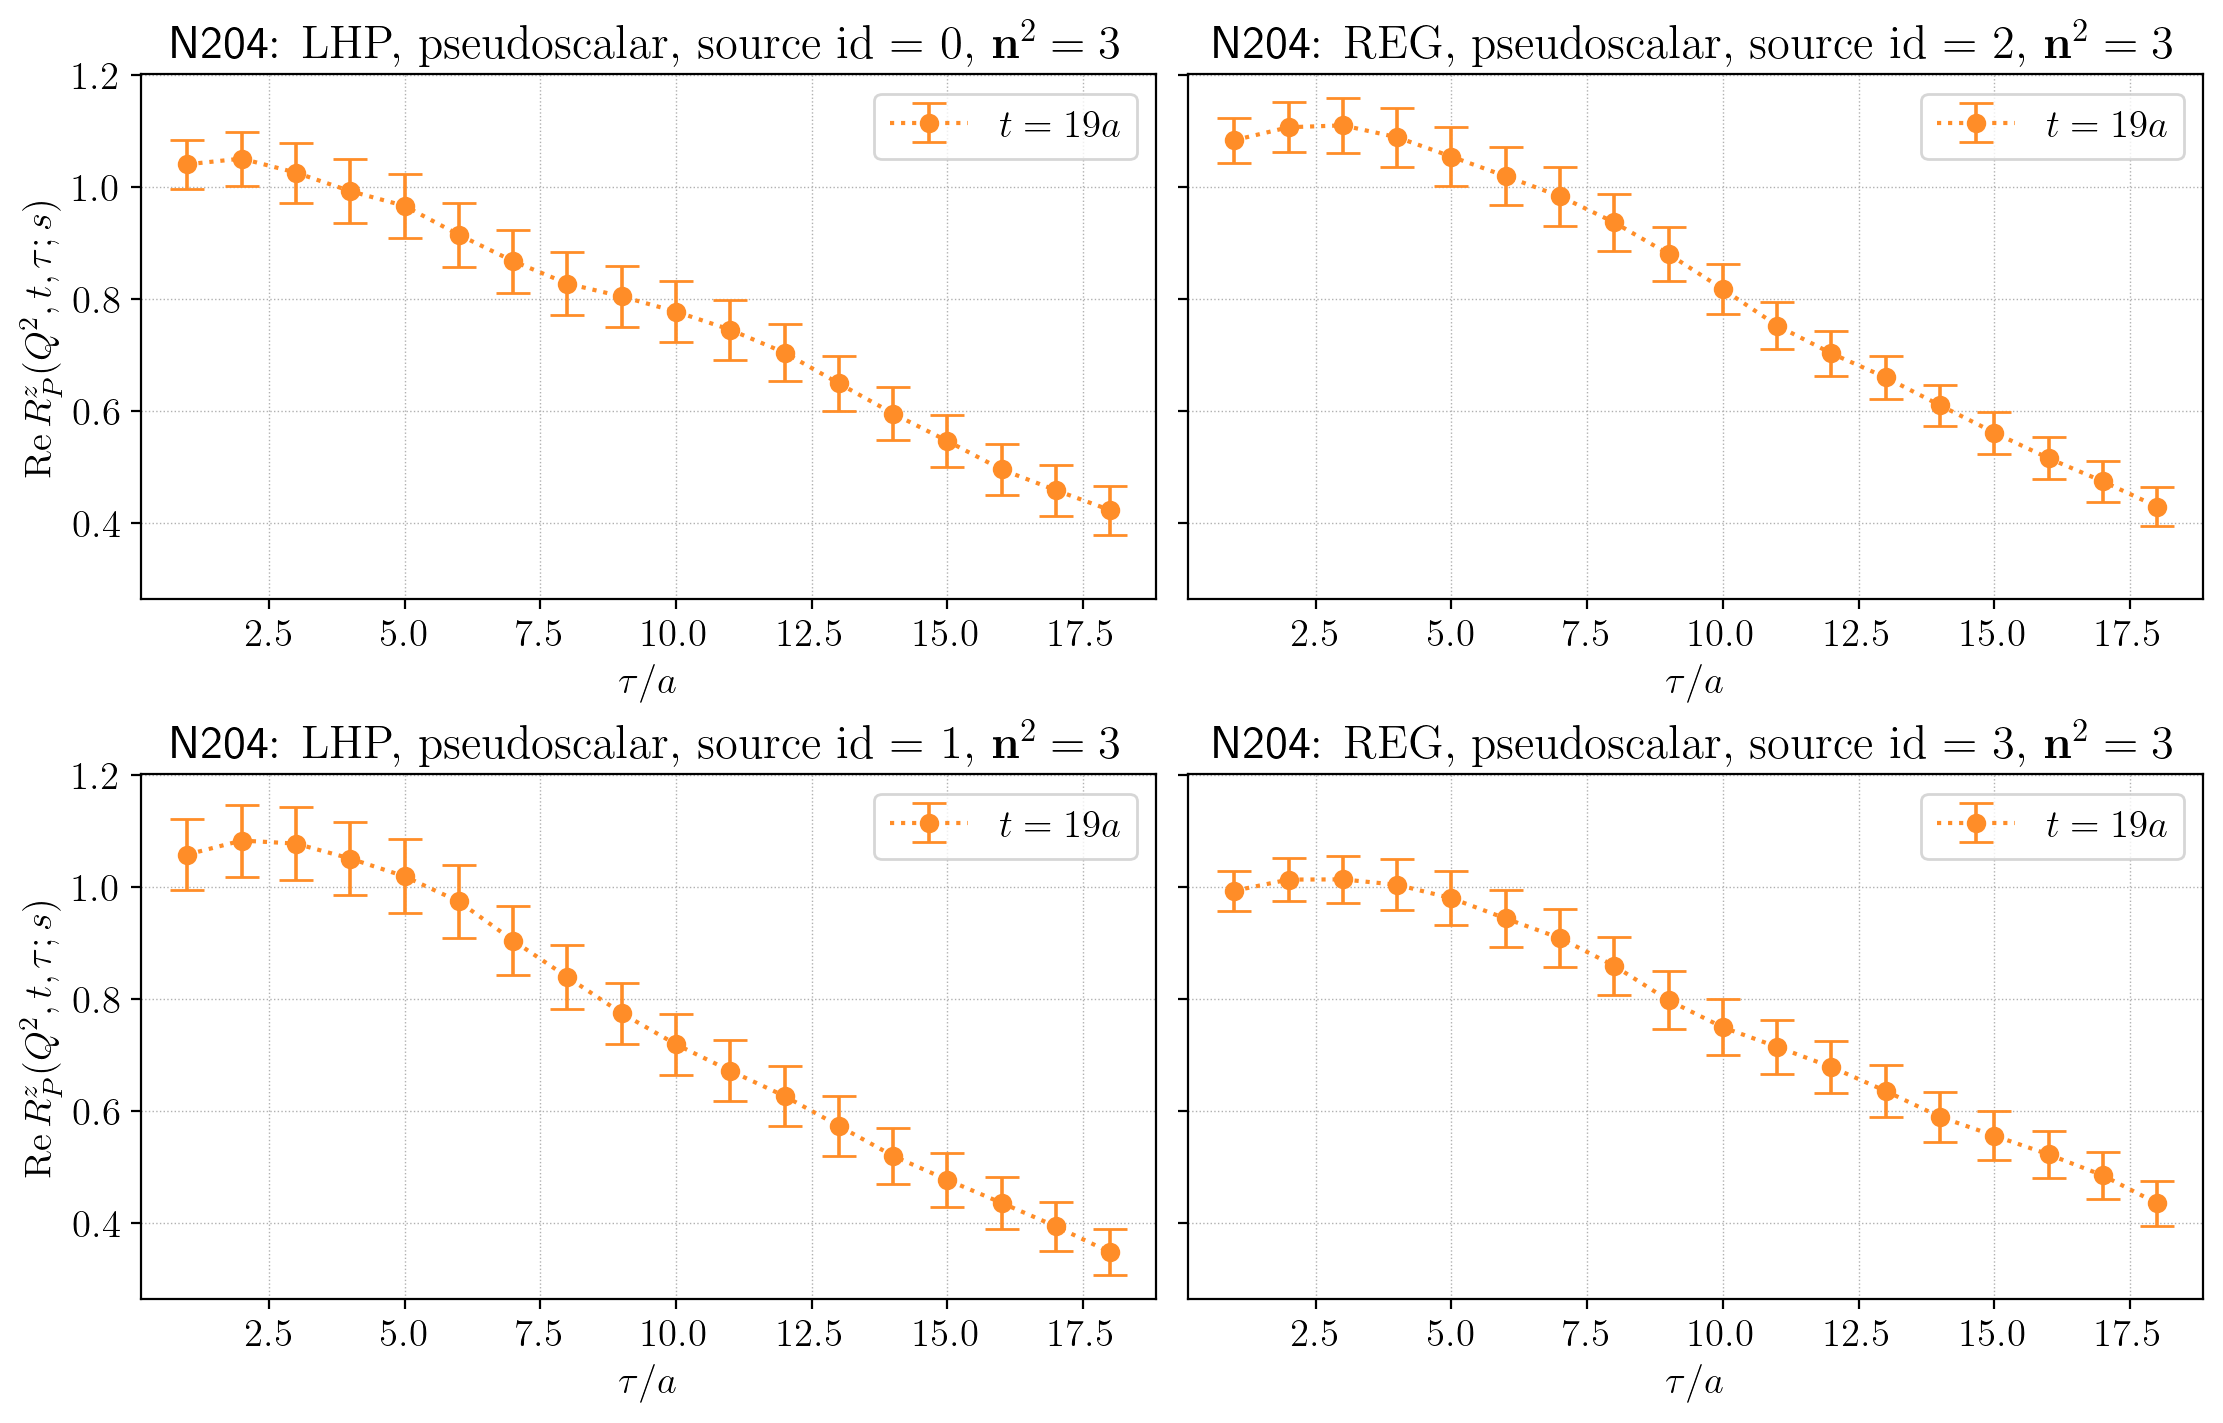

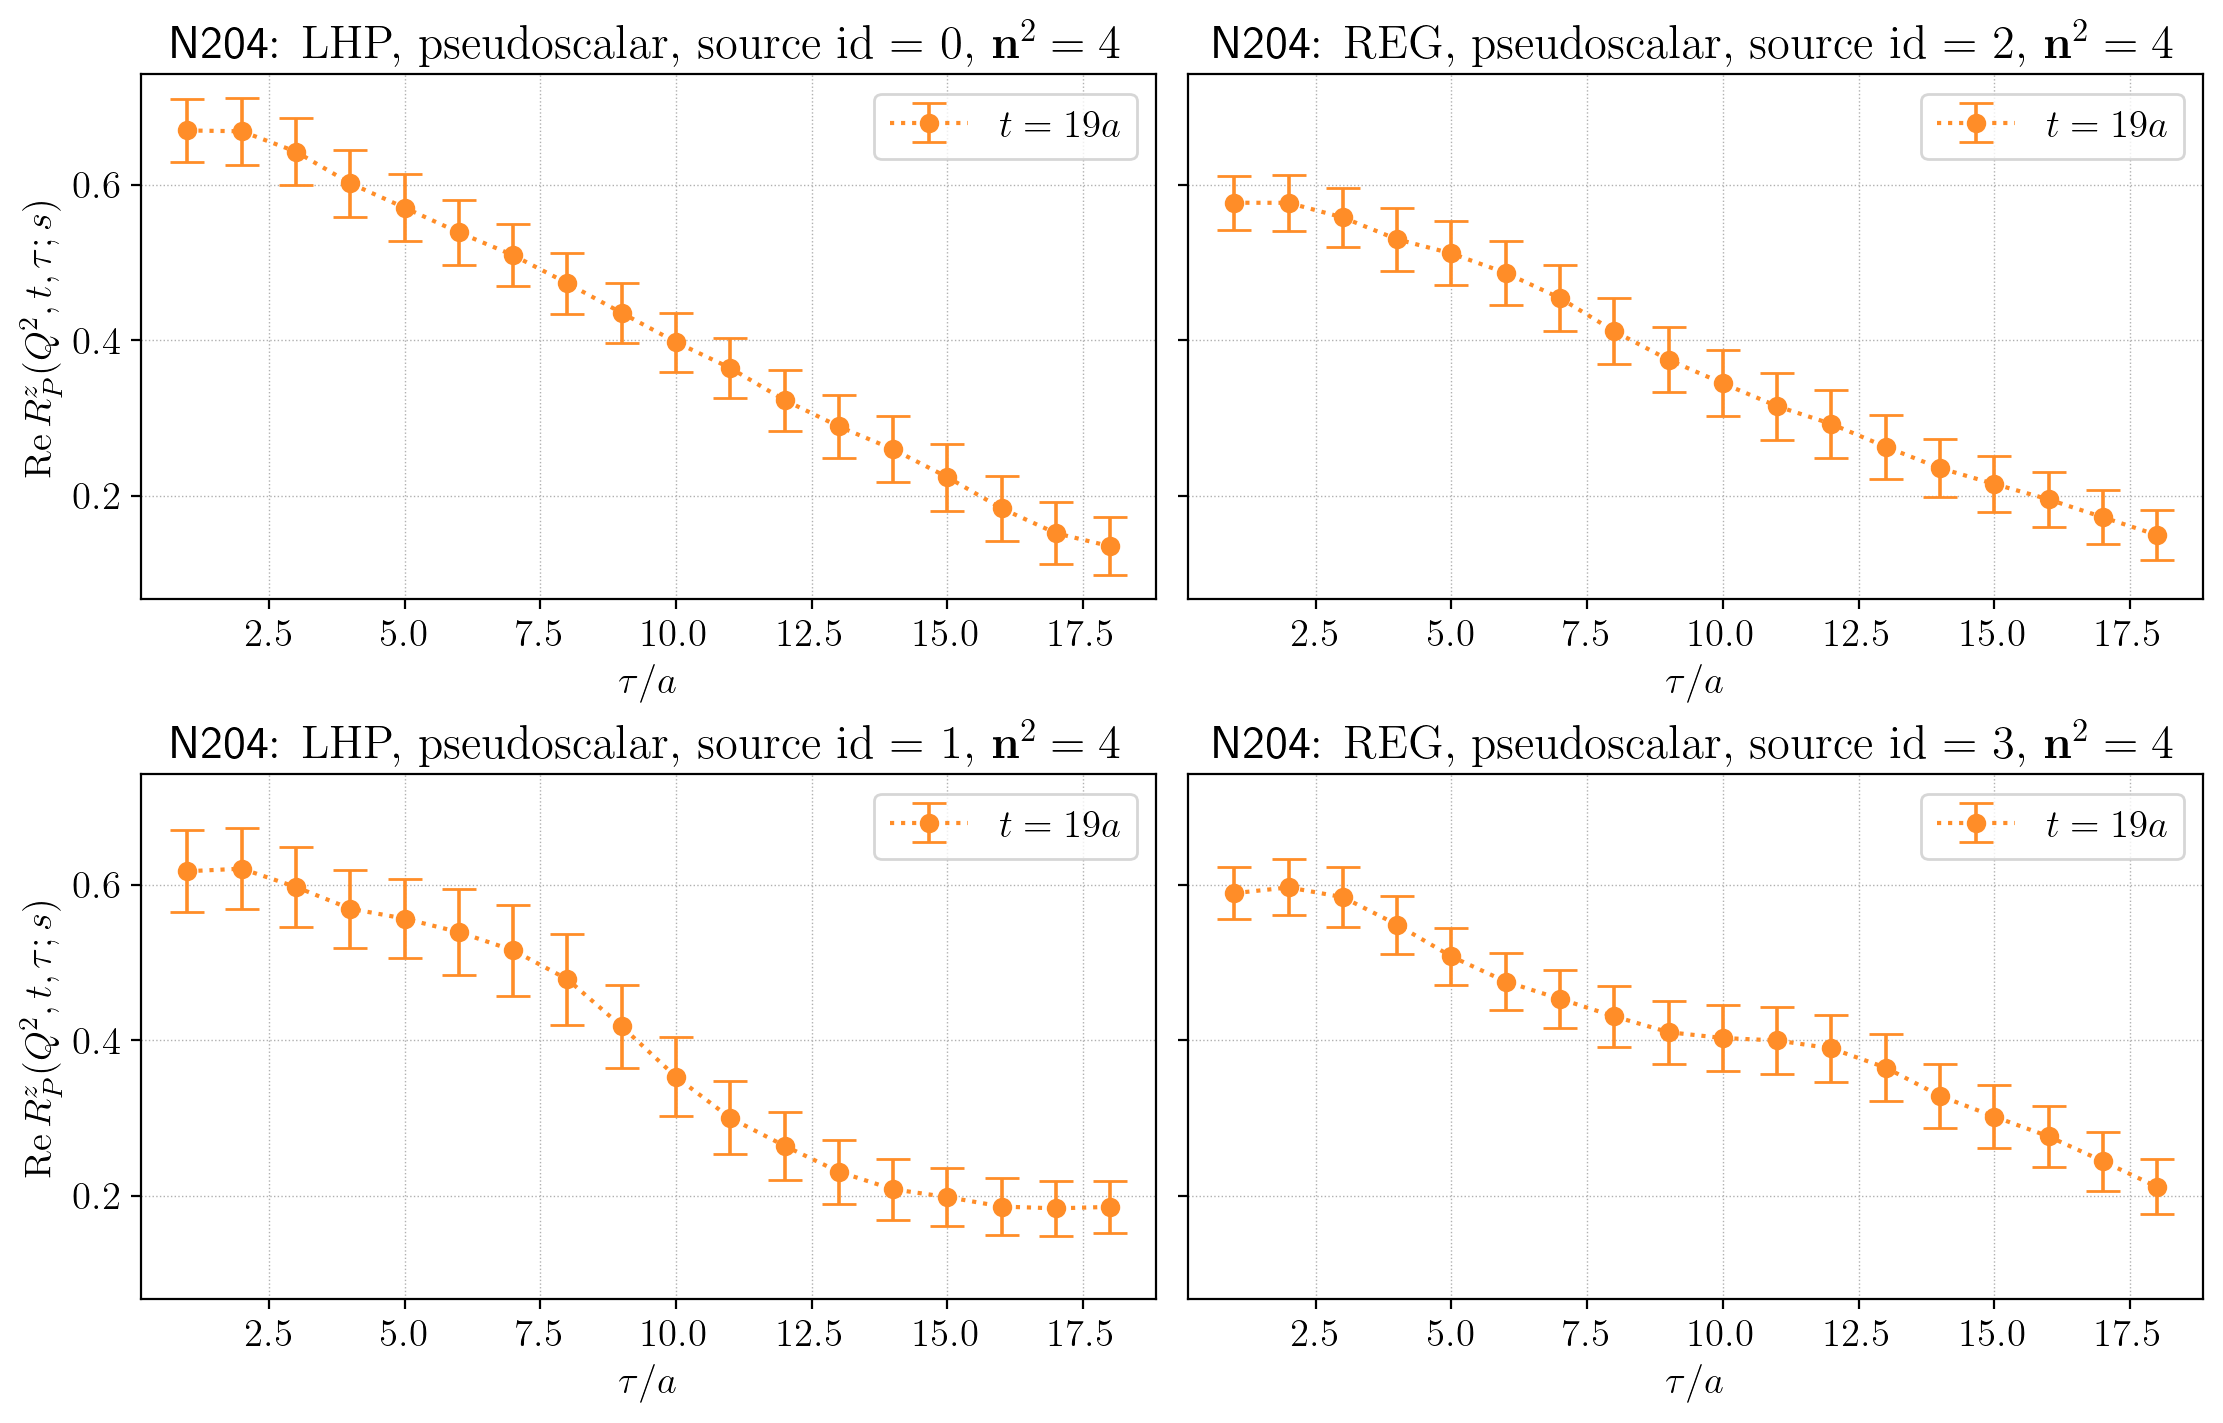

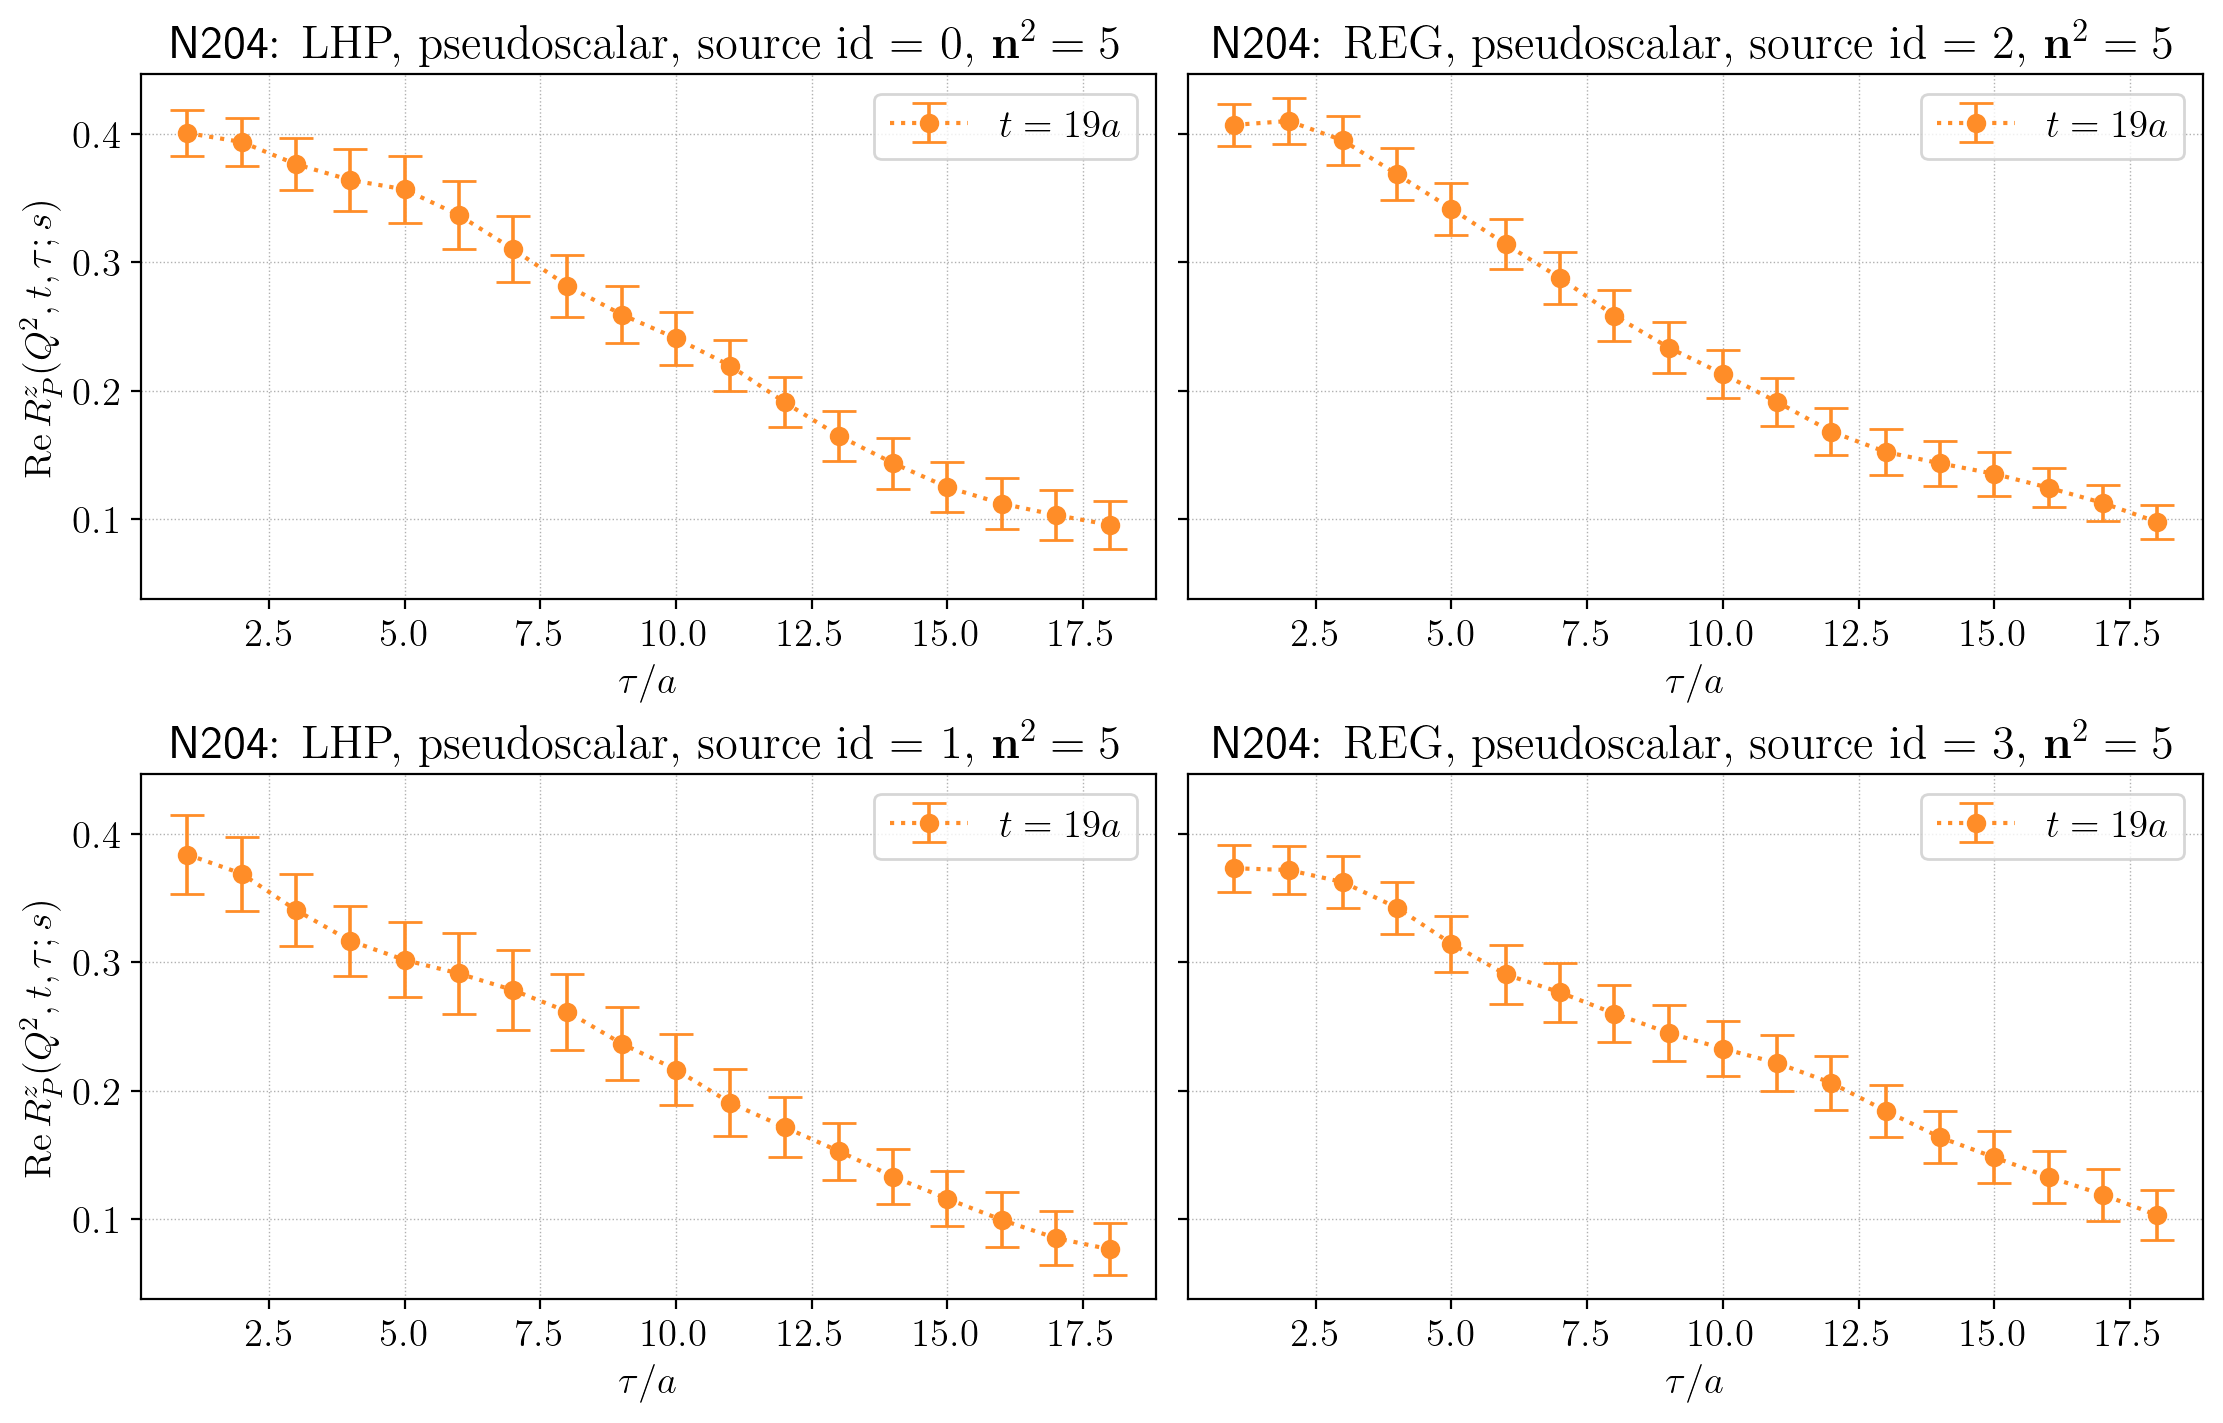

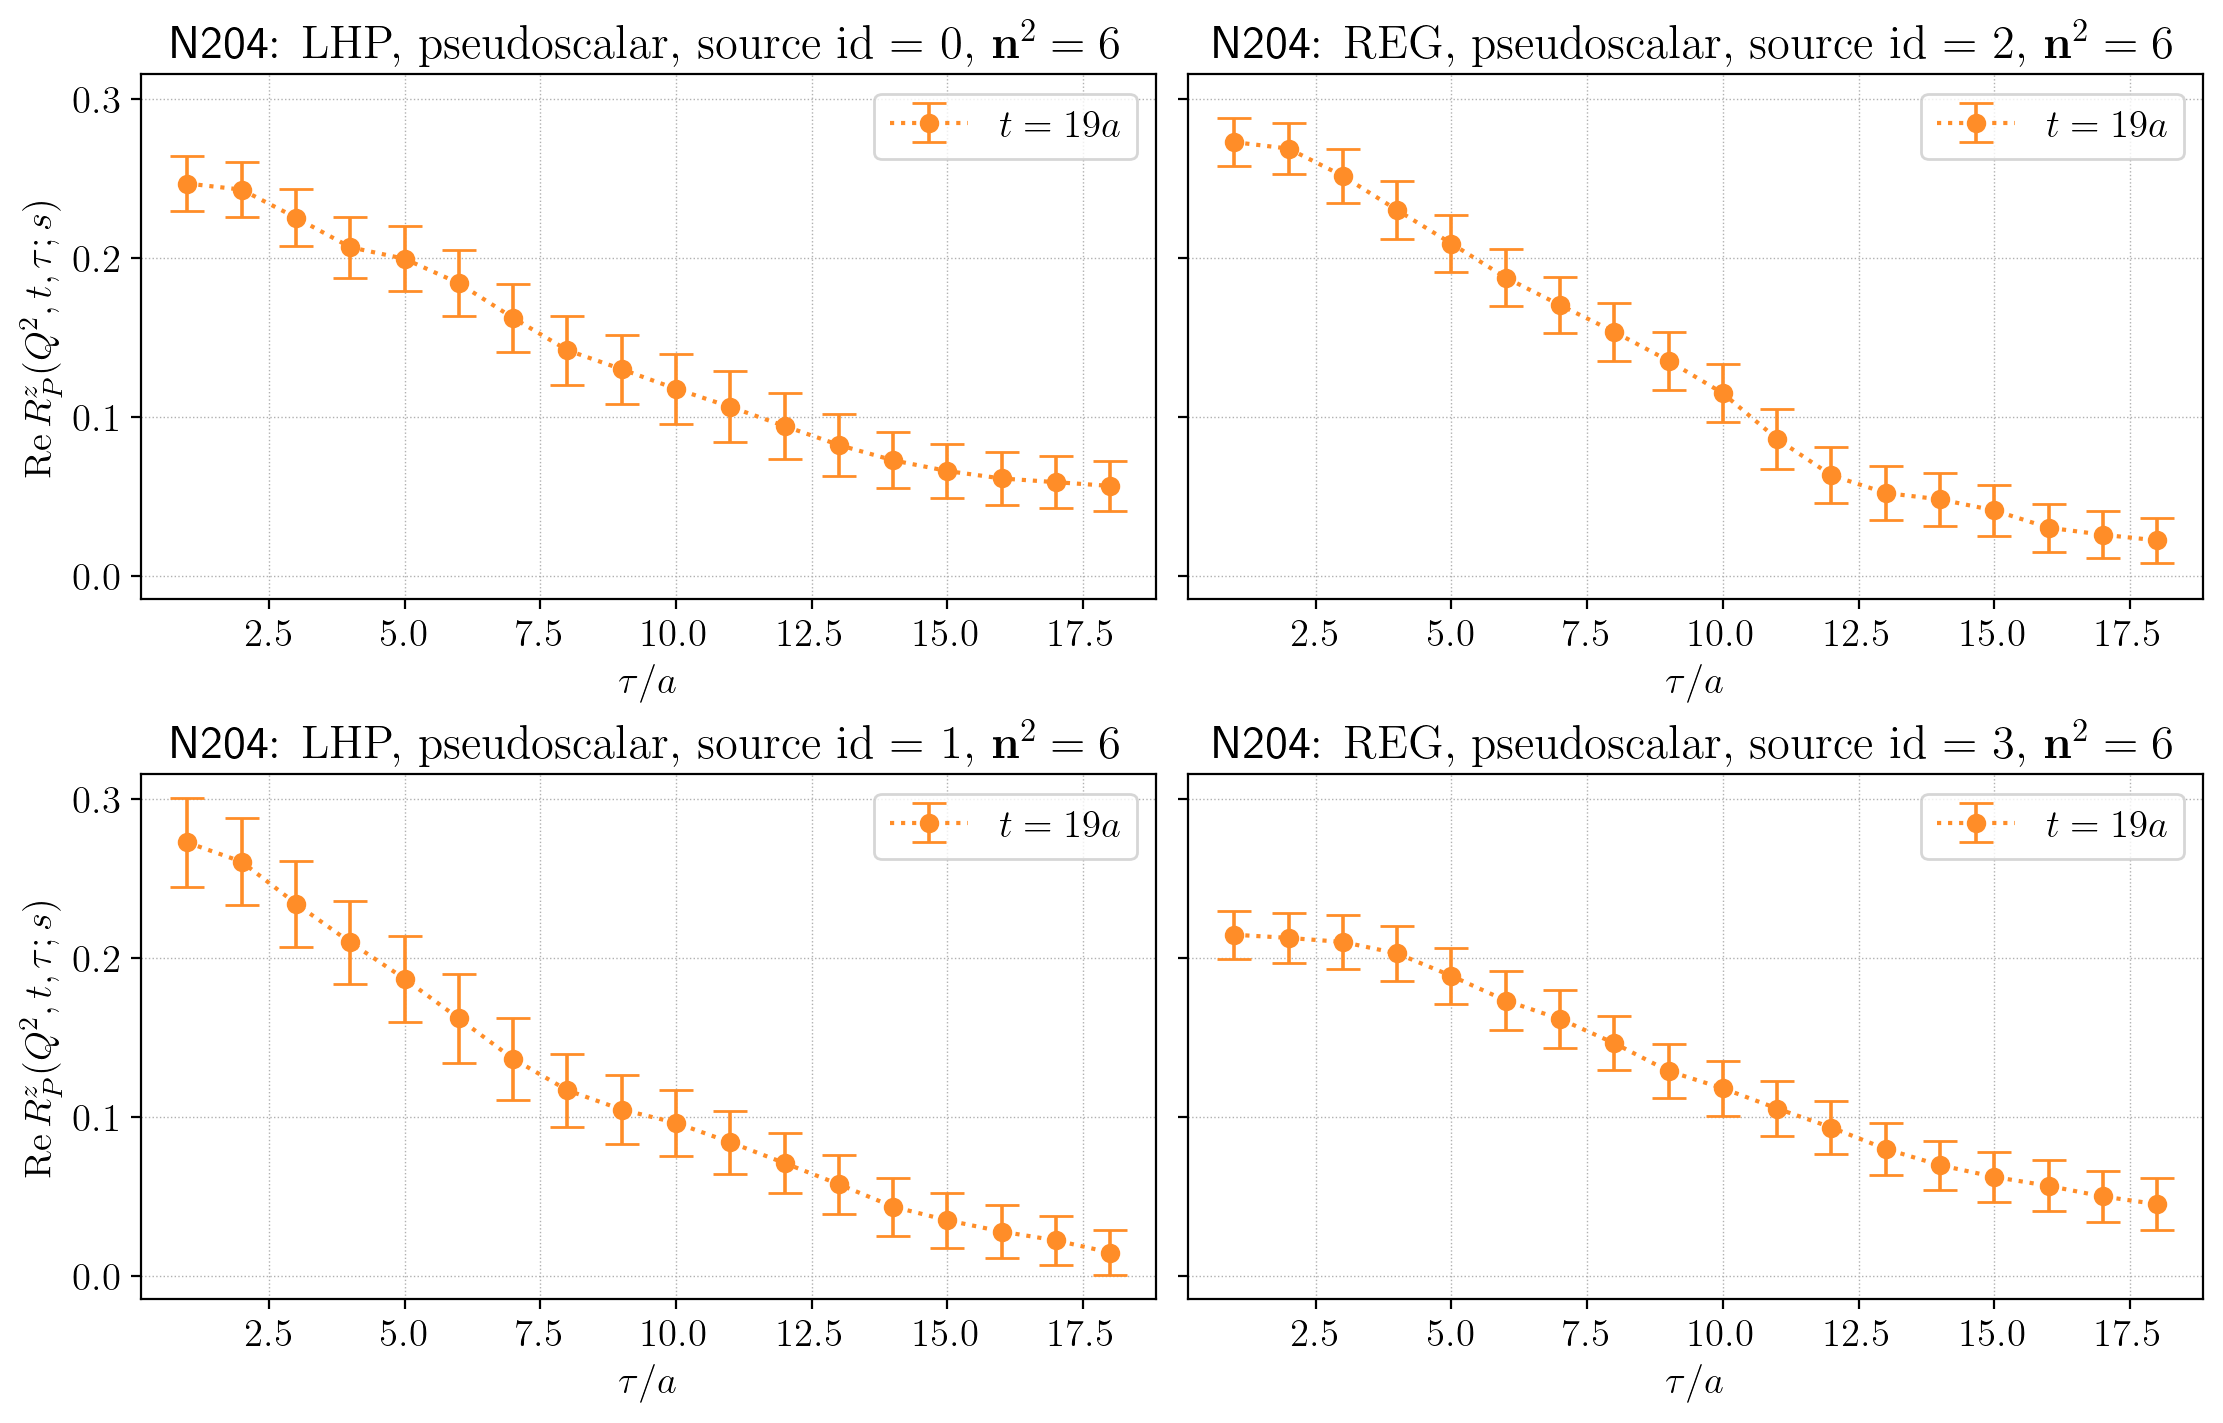

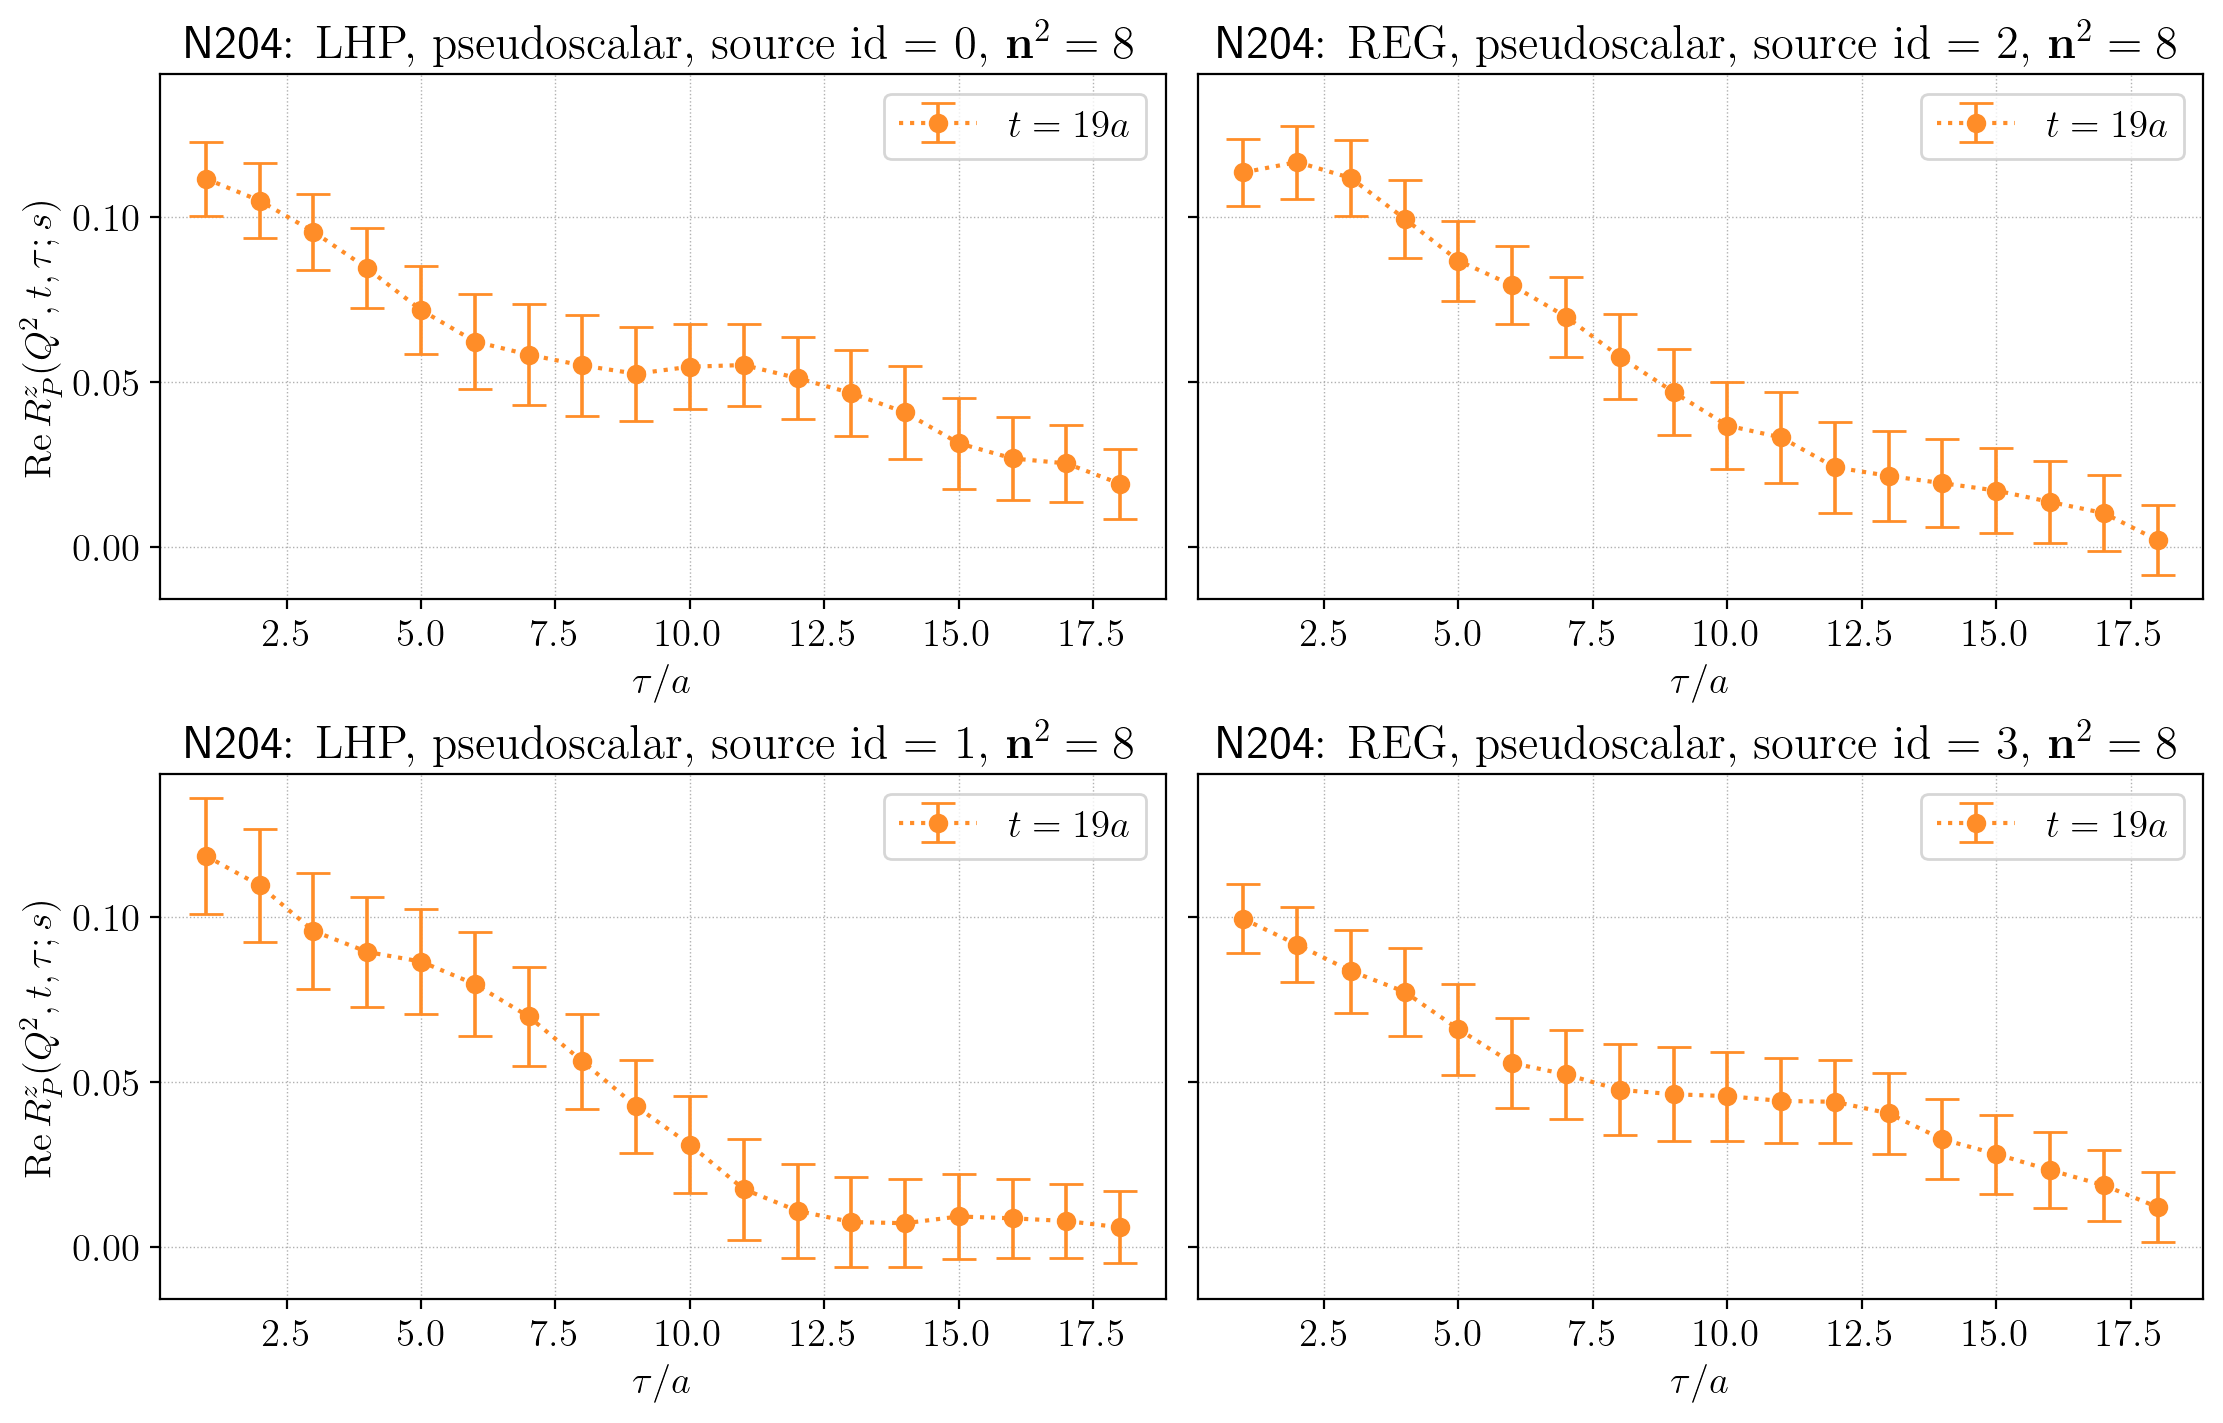

In [8]:
src_ids     = [0,1,2,3]
lhp_src_ids = [0,1]

src_position = {
    0: (0, 0),
    1: (1, 0),
    2: (0, 1),
    3: (1, 1),
}

data_s = ratios_per_nsquare['2']  # only source_set2

for n in nsquares:

    # skip nsquares not present (e.g. n=0 after polarisation filtering)
    if n not in data_s:
        continue

    fig, axs = plt.subplots(
        nrows=2,
        ncols=2,
        figsize=(11,7),
        sharey=True,
        constrained_layout=True
    )

    for src_id in src_ids:

        row, col = src_position[src_id]
        ax = axs[row, col]

        label = "LHP" if src_id in lhp_src_ids else "REG"

        ax.set_title(
            rf"$\mathsf{{{ensemble}}}$: {label}, pseudoscalar, source id = {src_id}, "
            rf"$\mathbf{{n}}^2 = {n}$"
        )

        for t in [19]:
            # guard missing tsep for this n
            if t not in data_s[n]:
                continue

            x = x_vals(n, t)
            y_est, y_err = y_est_err(data_s, src_id, n, t)

            # print(f"n^2={n}, src_id={src_id}, t={t}")
            # print("CENTRAL VALUES")
            # print(y_est)
            # print()
            # print("STANDARD ERRORS")
            # print(y_err)

            ax.errorbar(
                x[1:-1],
                y_est[1:-1],
                y_err[1:-1],
                marker=t_marker[t],
                markersize=6,
                capsize=6,
                color=t_color[t],
                linestyle=":",
                elinewidth=elinewidth,
                label=rf"$t={t}a$"
            )

        ax.grid(True, linestyle=":", linewidth=0.5)
        ax.set_xlabel(r"$\tau/a$")

        if col == 0:
            ax.set_ylabel(r"$\mathrm{Re}\,R_P^{z}(Q^2, t, \tau; s)$")

        ax.legend()

    plt.show()